<h1 style="font-family: 'Georgia', serif; text-align: center; font-weight: normal; margin-bottom: 0px;">
  <em>Coding a Forward Pass</em>
</h1>
<p style="text-align: center; font-family: 'Georgia', serif; color: gray; margin-top: 5px;">
  Dense Layer & Activation Functions
</p>
<hr style="width: 50%; border: 1px solid #ddd;">

<center>
    <img src="Note-Images/f_pass.jpg">
</center>

# Importing Data

In [4]:
pip install nnfs

Note: you may need to restart the kernel to use updated packages.


In [6]:
from nnfs.datasets import spiral_data
import matplotlib.pyplot as plt
import numpy as np

X,y = spiral_data(samples = 100, classes = 3)

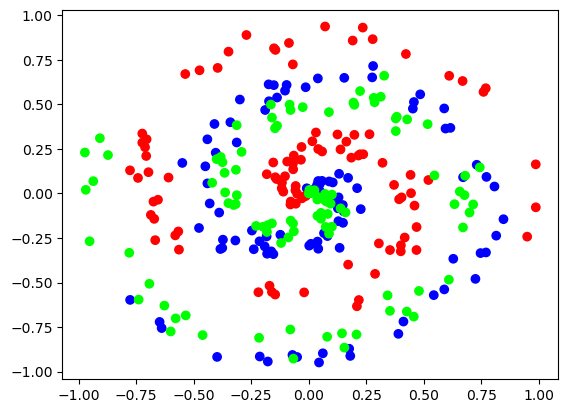

In [8]:
plt.scatter(X[:,0], X[:,1], c = y, cmap = 'brg')
plt.show()

# Dense Class

In [52]:
class Dense_Layer:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

    def forward_pass(self, inputs):
        self.output = np.dot(inputs, self.weights) + self.biases
        return self.output

# ReLU Class

In [46]:
class ReLU:
    def relu(self, inputs):
        self.output = np.maximum(0, inputs)
        return self.output

# Softmax Class

In [48]:
class softmax:
    def softmax(self, inputs):
        value = inputs - np.max(inputs, axis = 1, keepdims = True)
        exp_val = np.exp(value)
        self.output = exp_val / np.sum(exp_val, axis = 1, keepdims = True)
        return self.output

# Creating a forward pass

In [58]:
Layer1 = Dense_Layer(2,3)
layer1_output = Layer1.forward_pass(X)

activation1 = ReLU()
relu_output = activation1.relu(layer1_output)

layer2 = Dense_Layer(relu_output.shape[1], 3)
layer2_output = layer2.forward_pass(relu_output)

activation2 = softmax()
final_output = activation2.softmax(layer2_output)

print(final_output[:6,:])

[[0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]
 [0.33333332 0.33333329 0.33333339]
 [0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]]
